# Chapter-12. 猫狗分类实战

## 【章节目标】
- 掌握使用pytorch搭建猫狗分类的全流程模型训练流程
- 掌握pytorch模型保存和加载的方法
- 掌握使用GPU进行模型训练的方法

## 【章节内容】
### 12.1 猫狗分类实战
#### 1）定义DataSet

In [2]:
from torch.utils.data import Dataset
import random
from PIL import Image
import os
import numpy as np
random.seed(1)

class DogCatDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        """
        猫狗分类任务的Dataset
        :param data_dir: str, 数据集所在路径
        :param transform: torch.transform，数据预处理
        """
        self.label_name = {"cat": 0, "dog": 1}
        self.data_info = self.get_img_info(data_dir)  # data_info存储所有图片路径和标签，在DataLoader中通过index读取样本
        self.transform = transform

    def __getitem__(self, index):
        path_img, label = self.data_info[index]
        img = Image.open(path_img).convert('RGB')     # 0~255

        if self.transform is not None:
            img = self.transform(img)   # 在这里做transform，转为tensor等等

        return np.array(img), label

    def __len__(self):
        return len(self.data_info)

    def get_img_info(self,data_dir):
        data_info = list()
        for root, dirs, _ in os.walk(data_dir):
            # 遍历类别子目录
            for sub_dir in dirs:
                img_names = os.listdir(os.path.join(root, sub_dir))
                img_names = list(filter(lambda x: x.endswith('.jpg'), img_names))
                label=self.label_name[sub_dir]
                data_info.extend([(os.path.join(root, sub_dir, img),label) for img in img_names])#构造数据(path,label)
        return data_info

#### 2）定义DataLoader

In [3]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch
import numpy as np
def set_seed(seed=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seed()  # 设置随机种子

path='dog_vs_cat'
n_epochs = 3
batch_size_train = 16
batch_size_test = 32
learning_rate = 0.01
log_interval = 10

split_dir = os.path.join(path, "cad_split")
train_dir = os.path.join(split_dir, "train")
valid_dir = os.path.join(split_dir, "valid")

#定义预处理方法
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomCrop(224, padding=8),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


# 构建MyDataset实例
# train_data = DogCatDataset(data_dir=train_dir)
# valid_data = DogCatDataset(data_dir=valid_dir)
train_data = DogCatDataset(data_dir=train_dir, transform=train_transform)
valid_data = DogCatDataset(data_dir=valid_dir, transform=valid_transform)

# 构建DataLoder
train_loader = DataLoader(dataset=train_data, batch_size=batch_size_train, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size_test, num_workers=0, pin_memory=True)

#### 3）定义VGG16网络

In [4]:
# from collections import OrderedDict 之前用原生的OrderedDict，这次Block的网络用ModuleList能注册参数了
from torch import nn
import torch.nn.functional as F

class VGGBlock(nn.Module):
    def __init__(self, channels, kernel_size, padding, stride, activate=nn.ReLU()):
        '''
        channels:列表或元组，每层的输入通道数和输出通道数
        '''
        super(VGGBlock, self).__init__()
        self.layers=nn.ModuleList()#才实现了将添加进来的层参数进行注册
        for i in range(len(channels)-1):#遍历
            self.layers.append(nn.Conv2d(
                in_channels=channels[i], 
                out_channels=channels[i+1], 
                padding=padding, 
                kernel_size=kernel_size, 
                stride=stride))
            self.layers.append(activate)
            self.layers.append(nn.BatchNorm2d(num_features=channels[i+1]))
        self.layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    def forward(self, x):
        for layer in self.layers:
            x=layer(x)
        return x


class VGGNet(nn.Module):
    def __init__(self,num_classes):
        super(VGGNet, self).__init__()
        self.num_classes = num_classes
        #block1
        self.block1=VGGBlock([3,64,64],padding=1, kernel_size=3, stride=1)
        #block2
        self.block2=VGGBlock([64,128,128],padding=1, kernel_size=3, stride=1)
        #block3
        self.block3=VGGBlock([128,256,256,256],padding=1, kernel_size=3, stride=1)
        #block4
        self.block4=VGGBlock([256,512,512,512],padding=1, kernel_size=3, stride=1)
        #block5
        self.block5=VGGBlock([512,512,512,512],padding=1, kernel_size=3, stride=1)
        
        
        #classifier
        self.fc1=nn.Linear(in_features=512*7*7, out_features=4096)
        self.drop1=nn.Dropout(p=0.5)
        self.fc2=nn.Linear(in_features=4096, out_features=4096)
        self.drop2=nn.Dropout(p=0.5)
        self.fc3=nn.Linear(in_features=4096, out_features=self.num_classes)
        
    def forward(self, x):
        x=self.block1(x)
        x=self.block2(x)
        x=self.block3(x)
        x=self.block4(x)
        x=self.block5(x)
        
        x = x.view(x.size(0), -1)
        
        #classifier
        x = self.drop1(F.relu(self.fc1(x)))
        x = self.drop2(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

#### 4）定义损失函数和优化器

In [5]:
learning_rate = 0.0001
model=VGGNet(num_classes=2)
loss_func=nn.CrossEntropyLoss() #如果用NLLLoss，在网络里面就要做log_softmax
optimizer=torch.optim.Adam(model.parameters(), lr=learning_rate)

#### 5）搭建训练流程

In [ ]:
from tqdm import tqdm
n_epochs=20
log_interval = 100
#定义计算准确率的函数
def calc_acc(output,target):
    pred = output.argmax(dim=1)
    num_correct = torch.eq(pred, target).sum().float().item()#计算准确率
    return num_correct,num_correct/pred.shape[0]


for epoch in  range(n_epochs):
    model.train()#修改为训练模式
    train_loss=0#累计本轮此所有批次的损失值
    train_num_correct=0#累计本轮此正确分类样本的个数
    
    #训练
    for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
        optimizer.zero_grad()#梯度清零
        output = model(data)#前向传播
        loss = loss_func(output, target)#损失计算
        loss.backward()#反向传播
        optimizer.step()#更新参数
        train_loss += float(loss.item())#获取本来批次损失之并累加
        num_correct,acc=calc_acc(output,target)#计算本批次的准确率acc
        train_num_correct+=num_correct#将正确分类样本个数进行累加
        
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}\tACC: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item(),acc))

    print("Train Epoch: {}\t Loss: {:.6f}\t Acc: {:.6f}".format(epoch,
                                                                train_loss/len(train_loader),
                                                                train_num_correct/len(train_loader.dataset)))
    
    #验证
    val_loss=0#累计损失
    val_num_correct=0#累计验证集上正确分类的样本个数
    model.eval()#改为测试模式  1.不求导，2.dropout不起作用  3.bn层使用训练统计得到的均值和标准差
    for batch_idx, (data, target) in enumerate(valid_loader):
        output = model(data)#前向传播
        loss = loss_func(output, target)#损失计算
        val_loss += float(loss.item())#累计损失
        num_correct,_=calc_acc(output,target)#计算准确率
        val_num_correct+=num_correct#累计正确样本个数
    print("Val Epoch: {}\t Loss: {:.6f}\t Acc: {:.6f}".format(epoch,
                                                            val_loss/len(valid_loader),
                                                            val_num_correct/len(valid_loader.dataset)))
        

  0%|          | 1/1250 [00:04<1:40:34,  4.83s/it]

Train Epoch: 0 [0/20000 (0%)]	Loss: 2.044464	ACC: 0.312500


  3%|▎         | 34/1250 [02:56<1:47:01,  5.28s/it]

### 12.2 使用GPU进行模型训练
#### 1）单个GPU使用
- 判断GPU是否可用：torch.cuda.is_available()
- 将Tensor转移到GPU存储：XXX.to('cuda')

**使用方式：**

1.构建网络时，把网络，与损失函数转换到GPU上

In [ ]:
model = get_model()
loss_f = t.nn.CrossEntropyLoss()
if torch.cuda.is_available():
    model = model.cuda() #model.to('cuda')
    loss_f = loss_f.cuda()

2.训练网络时，把数据转换到GPU上

In [ ]:
if (use_gpu):
    x,y = x.cuda(),y.cuda()#将训练数据从内存转移导gpu

3.取出数据时，需要从GPU准换到CPU上进行操作

In [ ]:
if(use_gpu):
    loss = loss.cpu()
    acc = acc.cpu()

#### 2）改写猫狗分类为gpu和cpu通用版本

In [2]:
from torch.utils.data import Dataset
import random
from PIL import Image
import os
import numpy as np
random.seed(1)

class DogCatDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        """
        猫狗分类任务的Dataset
        :param data_dir: str, 数据集所在路径
        :param transform: torch.transform，数据预处理
        """
        self.label_name = {"cat": 0, "dog": 1}
        self.data_info = self.get_img_info(data_dir)  # data_info存储所有图片路径和标签，在DataLoader中通过index读取样本
        self.transform = transform

    def __getitem__(self, index):#负责未来的数据读取
        path_img, label = self.data_info[index]  #到文件中根据路径读取图片  会耗一定的时间
        img = Image.open(path_img).convert('RGB')     # 0~255

        if self.transform is not None:
            img = self.transform(img)   # 在这里做transform，转为tensor等等

        return np.array(img), label

    def __len__(self):
        return len(self.data_info)

    def get_img_info(self,data_dir):
        data_info = list()
        for root, dirs, _ in os.walk(data_dir):
            # 遍历类别子目录
            for sub_dir in dirs:
                img_names = os.listdir(os.path.join(root, sub_dir))
                img_names = list(filter(lambda x: x.endswith('.jpg'), img_names))
                label=self.label_name[sub_dir]
                data_info.extend([(os.path.join(root, sub_dir, img),label) for img in img_names])#构造数据(path,label)
        return data_info

In [3]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch
import numpy as np
def set_seed(seed=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seed()  # 设置随机种子

path='dog_vs_cat'
n_epochs = 3
batch_size_train = 16 # RTX2080s-mq (mobile) 7.0/8.0G cpu负责读取数据然后丢给gpu计算
batch_size_test = 32
learning_rate = 0.01
log_interval = 10

split_dir = os.path.join(path, "cad_split")
train_dir = os.path.join(split_dir, "train")
valid_dir = os.path.join(split_dir, "valid")

#定义预处理方法
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomCrop(224, padding=8),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


# 构建MyDataset实例
# train_data = DogCatDataset(data_dir=train_dir)
# valid_data = DogCatDataset(data_dir=valid_dir)
train_data = DogCatDataset(data_dir=train_dir, transform=train_transform)
valid_data = DogCatDataset(data_dir=valid_dir, transform=valid_transform)

# 构建DataLoder num_workers=8在win下可能会报错  jupyter中可以使用pin_memory=True表示限制只能用物理内存
train_loader = DataLoader(dataset=train_data, batch_size=batch_size_train, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size_test, num_workers=0, pin_memory=True)

In [4]:
from collections import OrderedDict
from torch import nn
import torch.nn.functional as F
class VGGBlock(nn.Module):
    def __init__(self,channels,kernel_size,padding,stride,activate=nn.ReLU()):
        '''
        channels:列表或元组，每层的输入通道数和输出通道数
        '''
        super(VGGBlock, self).__init__()
        self.layers=nn.ModuleList()
        for i in  range(len(channels)-1):#遍历
            self.layers.append(nn.Conv2d(
                in_channels=channels[i], 
                out_channels=channels[i+1], 
                padding=padding, 
                kernel_size=kernel_size, 
                stride=stride))
            self.layers.append(activate)
            self.layers.append(nn.BatchNorm2d(num_features=channels[i+1]))
        self.layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    def forward(self, x):
        for layer in self.layers:
            x=layer(x)
        return x


class VGGNet(nn.Module):
    def __init__(self,num_classes):
        super(VGGNet, self).__init__()
        self.num_classes = num_classes
        #block1
        self.block1=VGGBlock([3,64,64],padding=1, kernel_size=3, stride=1)
        #block2
        self.block2=VGGBlock([64,128,128],padding=1, kernel_size=3, stride=1)
        #block3
        self.block3=VGGBlock([128,256,256,256],padding=1, kernel_size=3, stride=1)
        #block4
        self.block4=VGGBlock([256,512,512,512],padding=1, kernel_size=3, stride=1)
        #block5
        self.block5=VGGBlock([512,512,512,512],padding=1, kernel_size=3, stride=1)
        
        
        #classifier
        self.fc1=nn.Linear(in_features=512*7*7, out_features=4096)
        self.drop1=nn.Dropout(p=0.5)
        self.fc2=nn.Linear(in_features=4096, out_features=4096)
        self.drop2=nn.Dropout(p=0.5)
        self.fc3=nn.Linear(in_features=4096, out_features=self.num_classes)
        
    def forward(self, x):
        x=self.block1(x)
        x=self.block2(x)
        x=self.block3(x)
        x=self.block4(x)
        x=self.block5(x)
        
        x = x.view(x.size(0), -1)
        
        #classifier
        x = self.drop1(F.relu(self.fc1(x)))
        x = self.drop2(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

In [ ]:
from tqdm import tqdm
learning_rate = 0.0001
n_epochs = 20
log_interval = 100
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # 获取可用设备
model = VGGNet(num_classes = 2).to(device) # 将model转移到可用设备上
loss_func = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma = 0.9) # 加入了学习率调整

# 计算准确率函数
def calc_acc(output, target):
    pred = output.argmax(dim = 1)
    num_correct = torch.eq(pred, target).sum().float().item() # 计算准确率
    return num_correct, num_correct / pred.shape[0]

for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    train_num_correct = 0

    # train
    for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
        data = data.to(device) # x转移到可用设备
        target = target.to(device).to(torch.long) # y转移到可用设备
        optimizer.zero_grad()
        output = model(data)
        loss = loss_func(output, target)
        loss.backward()
        optimizer.step()
        train_loss += float(loss.cpu())
        num_correct, acc = calc_acc(output, target)
        train_num_correct += num_correct

        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:0f}%)]\tLoss: {:.6f}\tACC: {:.6f}'.format(
                epoch, batch_idx + len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item(), acc
            ))
    
    print("Train Epoch: {}\t Loss: {:.6f}\t Acc: {:.6f}".format(epoch,
                                                                train_loss/len(train_loader),
                                                                train_num_correct/len(train_loader.dataset)))
    
    scheduler.step() # 更新学习率
    torch.cuda.empty_cache() # 清空gpu缓存

    # 验证
    val_loss = 0
    val_num_correct = 0
    model.eval()
    for data, target in tqdm(valid_loader):
        data = data.to(device)
        target = target.to(device)
        with torch.no_grad(): # 不求导
            output = model(data)
            loss = loss_func(output, target)
        val_loss += float(loss.item())
        num_correct, _ = calc_acc(output, target)   
        val_num_correct += num_correct
    #   torch.cuda.empty_cache()
    print("Val Epoch: {}\t Loss: {:.6f}\t Acc: {:.6f}".format(epoch,
                                                            val_loss/len(valid_loader),
                                                            val_num_correct/len(valid_loader.dataset)))

  0%|          | 0/1250 [00:00<?, ?it/s]C:\Users\lenovo\AppData\Local\Temp\ipykernel_36320\3512176705.py:31: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  train_loss += float(loss.cpu())
  0%|          | 1/1250 [00:00<20:07,  1.03it/s]

Train Epoch: 0 [16/20000 (0.000000%)]	Loss: 0.669690	ACC: 0.500000


  8%|▊         | 101/1250 [00:37<06:39,  2.87it/s]

Train Epoch: 0 [116/20000 (8.000000%)]	Loss: 1.323921	ACC: 0.312500


 16%|█▌        | 201/1250 [01:10<05:45,  3.04it/s]

Train Epoch: 0 [216/20000 (16.000000%)]	Loss: 0.804997	ACC: 0.562500


 24%|██▍       | 301/1250 [01:45<05:35,  2.83it/s]

Train Epoch: 0 [316/20000 (24.000000%)]	Loss: 0.636739	ACC: 0.750000


 28%|██▊       | 354/1250 [02:05<05:19,  2.81it/s]

#### 3）改进数据读取方式

GPU可能利用率比较低，其原因为cpu读取数据和预处理数据的速度跟不上GPU计算的速度，导致GPU等待，浪费了计算资源，可以采取以下方法提高cpu读取数据的速度：

- 使用多进程读取数据：将DataLoader的numworks参数设为cpu核心个数。注意：win系统下可能会有问题

- 提前将图片数据读取到内存，训练时直接从内存读取数据

下面我们采用第二种方式改进代码：

In [8]:
from torch.utils.data import Dataset
import random
from PIL import Image
import os
import numpy as np
random.seed(1)

class DogCatDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        """
        猫狗分类任务的Dataset
        :param data_dir: str, 数据集所在路径
        :param transform: torch.transform，数据预处理
        """
        self.label_name = {"cat": 0, "dog": 1}
        self.data_info = self.get_img_info(data_dir)  # data_info存储所有图片路径和标签，在DataLoader中通过index读取样本
        
        ##提前将数据读取并resize后放到内存中
        self.data=[(Image.open(path_img).convert('RGB').resize((224,224)),label) for path_img,label in self.data_info]
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.data[index]
#         img = Image.open(path_img).convert('RGB')     # 0~255

        if self.transform is not None:
            img = self.transform(img)   # 在这里做transform，转为tensor等等

        return np.array(img), label

    def __len__(self):
        return len(self.data)
    
        
    def get_img_info(self,data_dir):
        data_info = list()
        for root, dirs, _ in os.walk(data_dir):
            # 遍历类别子目录
            for sub_dir in dirs:
                img_names = os.listdir(os.path.join(root, sub_dir))
                img_names = list(filter(lambda x: x.endswith('.jpg'), img_names))
                label=self.label_name[sub_dir]
                data_info.extend([(os.path.join(root, sub_dir, img),label) for img in img_names])#构造数据(path,label)
        return data_info

In [9]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch
import numpy as np
def set_seed(seed=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seed()  # 设置随机种子

path='dog_vs_cat'
batch_size_train = 16
batch_size_test=32

split_dir = os.path.join(path, "cad_split")
train_dir=os.path.join(split_dir,"train")
valid_dir=os.path.join(split_dir,"valid")

#定义预处理方法
train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),#由于dataset中img已经进行了resize
    transforms.RandomCrop(224, padding=8),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

valid_transform = transforms.Compose([
#     transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


# 构建MyDataset实例
# train_data = DogCatDataset(data_dir=train_dir)
# valid_data = DogCatDataset(data_dir=valid_dir)
train_data = DogCatDataset(data_dir=train_dir, transform=train_transform)
valid_data = DogCatDataset(data_dir=valid_dir, transform=valid_transform)

# 构建DataLoder
train_loader = DataLoader(dataset=train_data, batch_size=batch_size_train, shuffle=True,pin_memory=True)
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size_test,pin_memory=True)

In [10]:
from torch import nn
import torch.nn.functional as F
class VGGBlock(nn.Module):
    def __init__(self,channels,kernel_size,padding,stride,activate=nn.ReLU()):
        '''
        channels:列表或元组，每层的输入通道数和输出通道数
        '''
        super(VGGBlock, self).__init__()
        self.layers=nn.ModuleList()
        for i in  range(len(channels)-1):#遍历
            self.layers.append(nn.Conv2d(
                in_channels=channels[i], 
                out_channels=channels[i+1], 
                padding=padding, 
                kernel_size=kernel_size, 
                stride=stride))
            self.layers.append(activate)
            self.layers.append(nn.BatchNorm2d(num_features=channels[i+1]))
        self.layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    def forward(self, x):
        for layer in self.layers:
            x=layer(x)
        return x


class VGGNet(nn.Module):
    def __init__(self,num_classes):
        super(VGGNet, self).__init__()
        self.num_classes = num_classes
        #block1
        self.block1=VGGBlock([3,64,64],padding=1, kernel_size=3, stride=1)
        #block2
        self.block2=VGGBlock([64,128,128],padding=1, kernel_size=3, stride=1)
        #block3
        self.block3=VGGBlock([128,256,256,256],padding=1, kernel_size=3, stride=1)
        #block4
        self.block4=VGGBlock([256,512,512,512],padding=1, kernel_size=3, stride=1)
        #block5
        self.block5=VGGBlock([512,512,512,512],padding=1, kernel_size=3, stride=1)
        
        
        #classifier
        self.fc1=nn.Linear(in_features=512*7*7, out_features=4096)
        self.drop1=nn.Dropout(p=0.5)
        self.fc2=nn.Linear(in_features=4096, out_features=4096)
        self.drop2=nn.Dropout(p=0.5)
        self.fc3=nn.Linear(in_features=4096, out_features=self.num_classes)
        
    def forward(self, x):
        x=self.block1(x)
        x=self.block2(x)
        x=self.block3(x)
        x=self.block4(x)
        x=self.block5(x)
        
        x = x.view(x.size(0), -1)
        
        #classifier
        x = self.drop1(F.relu(self.fc1(x)))
        x = self.drop2(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

In [11]:
#定义计算准确率的函数
def calc_acc(output,target):
    pred = output.argmax(dim=1)
    num_correct = torch.eq(pred, target).sum().float().item()#计算准确率
    return num_correct,num_correct/pred.shape[0]

In [5]:
from tqdm import tqdm
learning_rate = 0.0001
n_epochs=20
log_interval = 100
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model=VGGNet(num_classes=2).to(device)
loss_func=nn.CrossEntropyLoss().to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)


for epoch in  range(n_epochs):
    model.train()
    train_loss=0
    train_num_correct=0
    
    #训练
    for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
        data=data.to(device)
        target=target.to(device).to(torch.long)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_func(output, target)
        loss.backward()
        optimizer.step()
        train_loss += float(loss.cpu())
        num_correct,acc=calc_acc(output,target)
        train_num_correct+=num_correct
        
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}\tACC: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item(),acc))

    print("Train Epoch: {}\t Loss: {:.6f}\t Acc: {:.6f}".format(epoch,
                                                                train_loss/len(train_loader),
                                                                train_num_correct/len(train_loader.dataset)))
    scheduler.step()
    torch.cuda.empty_cache()

    #验证
    val_loss=0
    val_num_correct=0
    model.eval()
    for data, target in tqdm(valid_loader):
        data=data.to(device)
        target=target.to(device)
        with torch.no_grad():
            output = model(data)
            loss = loss_func(output, target)
        val_loss += float(loss.item())
        num_correct,_=calc_acc(output,target)
        val_num_correct+=num_correct
#     torch.cuda.empty_cache()
    print("Val Epoch: {}\t Loss: {:.6f}\t Acc: {:.6f}".format(epoch,
                                                            val_loss/len(valid_loader),
                                                            val_num_correct/len(valid_loader.dataset)))
        

  0%|          | 0/1250 [00:00<?, ?it/s]C:\Users\lenovo\AppData\Local\Temp\ipykernel_41108\3195004290.py:26: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  train_loss += float(loss.cpu())
  0%|          | 1/1250 [00:00<16:09,  1.29it/s]

Train Epoch: 0 [0/20000 (0%)]	Loss: 0.642420	ACC: 0.500000


  8%|▊         | 101/1250 [00:33<05:51,  3.27it/s]

Train Epoch: 0 [1600/20000 (8%)]	Loss: 1.273539	ACC: 0.500000


 16%|█▌        | 201/1250 [01:05<05:31,  3.16it/s]

...

Train Epoch: 19 [19200/20000 (96%)]	Loss: 0.011157	ACC: 1.000000


100%|██████████| 1250/1250 [13:23<00:00,  1.56it/s]


Train Epoch: 19	 Loss: 0.048402	 Acc: 0.981850


100%|██████████| 79/79 [00:20<00:00,  3.92it/s]

Val Epoch: 19	 Loss: 0.094737	 Acc: 0.973600


In [8]:
print(model.state_dict())

OrderedDict([('block1.layers.0.weight', tensor([[[[ 0.0913, -0.0951, -0.0497],
          [ 0.0829, -0.1886,  0.1075],
          [-0.0490,  0.0911,  0.0210]],

         [[-0.0255,  0.0472,  0.0017],
          [ 0.0679, -0.0786, -0.0175],
          [-0.0217,  0.0258, -0.0016]],

         [[ 0.1692,  0.0573, -0.0749],
          [-0.1151, -0.0320, -0.0817],
          [-0.0628,  0.0107,  0.1178]]],


        [[[ 0.0993, -0.1947,  0.1087],
          [ 0.0462,  0.1677,  0.1189],
          [-0.1821, -0.1937, -0.1015]],

         [[ 0.1792, -0.0245,  0.0832],
          [-0.0820,  0.1871, -0.0793],
          [ 0.1509,  0.0033, -0.1003]],

         [[ 0.1064, -0.0960,  0.0569],
          [-0.0522, -0.0245, -0.1848],
          [-0.0902,  0.1007, -0.0494]]],


        [[[ 0.1967,  0.1476, -0.0131],
          [-0.1146,  0.1324,  0.0633],
          [-0.1164,  0.1415,  0.1252]],

         [[ 0.1690, -0.1165, -0.0375],
          [ 0.0025,  0.0333, -0.1473],
          [-0.1315,  0.1138, -0.0414]],

    

In [7]:
# 手动保存当前这 20 轮的结果
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'epoch': 19  # 因为是从0开始的，第20轮对应索引19
}
torch.save(checkpoint, 'model/vgg16_initial_20.pkl')
print("Saved")

Saved


#### 4）多GPU加速
这里我们介绍单主机多GPUs的情况，单机多GPUs主要采用的DataParallel函数，而不是DistributedParallel，后者一般用于多主机多GPUs，当然也可用于单机多GPU。

使用多卡训练的方式有很多，当然前提是我们的设备中存在两个及以上的GPU。

使用时直接用model传入torch.nn.DataParallel函数即可，如下代码：

In [ ]:
#对模型 net = torch.nn.DataParallel(model)

### 12.3 模型保存和加载
#### 1）模型参数保存和加载
- 保存：torch.save(model.state_dict(),path)-仅仅保存模型中的参数，模型本身的计算图不保存。

- 加载：model.load_state_dict(torch.load(path))-需要自己定义网络，并且其中的参数名称与结构要与保存的模型中的一致（可以是部分网络，比如只使用VGG的前几层），相对灵活，便于对网络进行修改。

其中：

- model指定义的模型实例变量，如 model=vgg16( )

- path是保存参数的路径，如 path='./model.pth' , path='./model.tar', path='./model.pkl', 保存参数的文件一定要有后缀扩展名。

- torch.save：实现对象二进制序列化并保存

- torch.load： 实现二进制文件读取并反序列化成对象

#### 2）保存更多信息
特别地，如果还想保存某一次训练采用的优化器、epochs等信息，可将这些信息组合起来构成一个字典，然后将字典保存起来：

In [ ]:
state = {'model': model.state_dict(), 'optimizer': optimizer.state_dict(), 'epoch': epoch}
torch.save(state, path)

加载方式如下：

In [ ]:
checkpoint = torch.load(path) # 将序列化的字典读取进来，返回的就是保存的时候的字典
model.load_state_dict(checkpoint['model'])
optimizer.load_state_dict(checkpoint['optimizer'])
epoch = checkpoint(['epoch'])

#### 3）保存和加载整个模型

- 保存：torch.save(the_model, PATH)-同时保存网络结构和参数

- 加载：the_model = torch.load(PATH)-无需自定义网络，保存时已把网络结构保存，比较死板，不能调整网络结构。

In [ ]:
torch.save(model, path)
model2 = torch.load(PATH)

#### 4）猫狗分类模型保存实战
实现断点续传功能

checkpoint = {   
    'model_state_dict':model.state_dict(),   
    'optimizer_state_dict':optimizer.state_dict(),   
    'scheduler_state_dict':scheduler.state_dict(),   
    'epoch':epoch   
}

In [10]:
from tqdm import tqdm
learning_rate = 0.0001
n_epochs = 30
log_interval = 100
save_path='model/vgg16_initial_20.pkl' # 模型保存路径

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#####实例化各个对象####
model = VGGNet(num_classes = 2).to(device)
loss_func = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma = 0.9)
start_epoch = 0
#判断模型文件是否存在，存在则加载模型
if os.path.exists(save_path):
    checkpoint = torch.load(save_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1

max_acc = 0.0 # 保存模型应该选择acc最大的那一次进行保存
for epoch in  range(start_epoch,n_epochs):
    model.train()
    train_loss=0
    train_num_correct=0
    
    #训练
    for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
        data = data.to(device)
        target = target.to(device).to(torch.long)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_func(output, target)
        loss.backward()
        optimizer.step()
        train_loss += float(loss.cpu())
        num_correct, acc = calc_acc(output,target)
        train_num_correct += num_correct
        
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}\tACC: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item(),acc))

    print("Train Epoch: {}\t Loss: {:.6f}\t Acc: {:.6f}".format(epoch,
                                                                train_loss/len(train_loader),
                                                                train_num_correct/len(train_loader.dataset)))
    scheduler.step()
    torch.cuda.empty_cache()

    # 验证
    val_loss = 0
    val_num_correct = 0
    model.eval()
    for data, target in tqdm(valid_loader):
        data = data.to(device)
        target = target.to(device)
        with torch.no_grad():
            output = model(data)
            loss = loss_func(output, target)
        val_loss += float(loss.item())
        num_correct, _ = calc_acc(output,target)
        val_num_correct += num_correct

    val_acc = val_num_correct / len(valid_loader.dataset)
    print("Val Epoch: {}\t Loss: {:.6f}\t Acc: {:.6f}".format(epoch,
                                                            val_loss/len(valid_loader),val_acc))
    
    if val_acc > max_acc: #判断验证集指标是否提升，若提升则保存模型
        max_acc = val_acc
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'epoch': epoch
        }
        torch.save(checkpoint, save_path) # 保存模型

  0%|          | 1/1250 [00:03<1:04:57,  3.12s/it]

Train Epoch: 20 [0/20000 (0%)]	Loss: 0.016902	ACC: 1.000000


  8%|▊         | 101/1250 [03:02<29:19,  1.53s/it]

Train Epoch: 20 [1600/20000 (8%)]	Loss: 0.286020	ACC: 0.937500


 13%|█▎        | 161/1250 [04:43<31:55,  1.76s/it]


KeyboardInterrupt: 

#### 5) 效果验证

成功加载第 20 轮的权重！


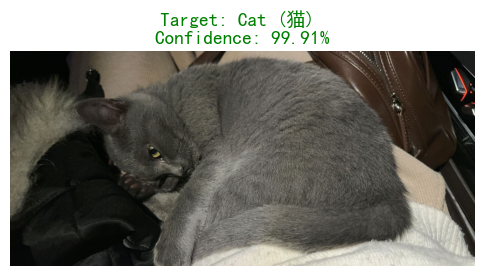

In [24]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决保存图像是负号'-'显示为方块的问题

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# 实例化模型并加载权重
save_path = 'model/vgg16_initial_20.pkl'
model = VGGNet(num_classes=2).to(device)

if os.path.exists(save_path):
    checkpoint = torch.load(save_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"成功加载第 {checkpoint['epoch'] + 1} 轮的权重！")
else:
    print("错误：未找到权重文件，请检查路径。")

model.eval() # 切换到推理模式

def predict_and_show(model, image_path, device):
    # 定义推理用的预处理（直接使用前面定义好的 valid_transform）
    # 注意：推理不需要 RandomCrop 和 RandomRotation
    inference_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 加载图片并转换
    raw_img = Image.open(image_path).convert('RGB')
    input_tensor = inference_transform(raw_img).unsqueeze(0).to(device)

    # 推理
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        # 将输出转为概率
        probs = F.softmax(output, dim=1)
        # 获取最大概率的索引和数值
        conf, pred_idx = torch.max(probs, 1)
        
    # 结果映射
    labels = {0: "Cat (猫)", 1: "Dog (狗)"}
    result_text = f"Target: {labels[pred_idx.item()]} \nConfidence: {conf.item():.2%}"

    # 可视化
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_img)
    plt.title(result_text, fontsize=14, color='red' if conf < 0.7 else 'green')
    plt.axis('off')
    plt.show()

# --- 调用 ---
# 确保model 已经 load_state_dict 了
test_img_path = "test_images/lanshuai.jpeg"
predict_and_show(model, test_img_path, device)